### Wasserstein distance

In [2]:
models = {
    # LLaMA 3.1
    "llama3.1-8b": "meta-llama/Llama-3.1-8B",
    "llama3.1-8b-inst": "meta-llama/Llama-3.1-8B-Instruct",
    
    # Meta-LLaMA 3 (alt naming from Meta)
    "meta-llama3-8b": "meta-llama/Meta-Llama-3-8B",
    "meta-llama3-8b-inst": "meta-llama/Meta-Llama-3-8B-Instruct",
    
    # LLaMA 3.2
    "llama3.2-3b": "meta-llama/Llama-3.2-3B",
    "llama3.2-3b-inst": "meta-llama/Llama-3.2-3B-Instruct",

    # LLaMA 2
    "llama2-7b": "meta-llama/Llama-2-7b-hf",
    "llama2-7b-chat": "meta-llama/Llama-2-7b-chat-hf",
    
    # Mistral
    "mistral-7b-inst": "mistralai/Mistral-7B-Instruct-v0.1",
    
    # Gemma
    "gemma-7b": "google/gemma-7b",
    "gemma-7b-it": "google/gemma-7b-it",
    
    # Qwen
    "qwen2.5-7b": "Qwen/Qwen2.5-7B",
    "qwen2.5-7b-inst": "Qwen/Qwen2.5-7B-Instruct"
}
datasets = {
    "A_AllSameLabel": "TrainDataAllYears/Ful_DatasetAllYears.csv",
}

type_prompts = ["NoSys"]
prompt_variants = [1,3]
iterations = [1,2,3] 
profile_path = "DataSurveyProfiles/CartesianProduct_SynteticData_2.csv"
metric = ['metrics_Australian Greens.json','metrics_Australian Labor Party.json' 'metrics_Liberal Party of Australia.json',
'metrics_National Party of Australia.json']

In [4]:
import os
import pandas as pd
import numpy as np
from scipy.stats import wasserstein_distance
from itertools import combinations

party_cols = ["Australian Greens", "Australian Labor Party", "Liberal Party of Australia", "National Party of Australia"]

def sigmoid_normalize(vec):
    sigmoid = 1 / (1 + np.exp(-vec))
    return sigmoid / sigmoid.sum()

full_results = []

barycenter_vectors = {}  

for model_short, MODEL_NAME in models.items():
    for dataset_short, CSV_PATH in datasets.items():
        barycenter_vectors[model_short] = {}
        barycenter_vectors[model_short][dataset_short] = {}

        for type_prompt in type_prompts:
            barycenter_vectors[model_short][dataset_short][type_prompt] = {}

            for prompt_variant in prompt_variants:
                persona_vectors = {}

                for iteration in iterations:
                    path_directory = f"top_val_vec_{model_short}_{dataset_short}{type_prompt}/"
                    file_name = f"scaling_matrix_{prompt_variant}_{iteration}.csv"
                    full_path = os.path.join(path_directory, file_name)

                    df = pd.read_csv(full_path)
                    df = df.set_index("persona_id")[party_cols]

                    for persona_id, row in df.iterrows():
                        if persona_id not in persona_vectors:
                            persona_vectors[persona_id] = []
                        normalized_vec = sigmoid_normalize(row.values)
                        persona_vectors[persona_id].append(normalized_vec)

                # Save mean vectors for system prompt comparison
                barycenter_vectors[model_short][dataset_short][type_prompt][prompt_variant] = {
                    persona_id: np.mean(vectors, axis=0)
                    for persona_id, vectors in persona_vectors.items()
                }

                # Pairwise iteration distances
                for persona_id, vectors in persona_vectors.items():
                    for (i, vi), (j, vj) in combinations(enumerate(vectors), 2):
                        dist = wasserstein_distance(vi, vj)
                        full_results.append({
                            "model": model_short,
                            "dataset": dataset_short,
                            "type_prompt": type_prompt,
                            "prompt_variant": prompt_variant,
                            "persona_id": persona_id,
                            "iteration_pair": f"{i+1}-{j+1}",
                            "wasserstein_distance": dist,
                            "type_measurement": "Pairwise_iteration"
                        })

                    # Barycenter distances
                    barycenter = np.mean(vectors, axis=0)
                    for i, vec in enumerate(vectors):
                        dist = wasserstein_distance(vec, barycenter)
                        full_results.append({
                            "model": model_short,
                            "dataset": dataset_short,
                            "type_prompt": type_prompt,
                            "prompt_variant": prompt_variant,
                            "persona_id": persona_id,
                            "iteration_pair": f"{i + 1}barycenter",
                            #"iteration_index": i + 1,
                            "wasserstein_distance": dist,
                            "type_measurement": "barycenter_iteration"
                        })

        # --- Prompt Variant Difference (per type_prompt) ---
        if len(prompt_variants) == 2:
            pv1, pv2 = prompt_variants
            for type_prompt in type_prompts:
                bvecs = barycenter_vectors[model_short][dataset_short][type_prompt]
                for persona_id in bvecs[pv1]:
                    if persona_id in bvecs[pv2]:
                        vec1 = bvecs[pv1][persona_id]
                        vec2 = bvecs[pv2][persona_id]
                        dist = wasserstein_distance(vec1, vec2)
                        full_results.append({
                            "model": model_short,
                            "dataset": dataset_short,
                            "type_prompt": type_prompt,
                            "prompt_variant": f"{pv1}-{pv2}",
                            "persona_id": persona_id,
                            "iteration_pair": "prompt_variant_diff",
                            "wasserstein_distance": dist,
                            "type_measurement": "prompt_variant"
                        })

result_full_df = pd.DataFrame(full_results)

In [ ]:
path_directory = f"full_wasserstein.csv"
result_full_df.to_csv(path_directory, index=False)

### Fig. 2. Mean Wasserstein distance (optimal transport cost) of scaling factor distributions across sociodemographic subgrou

In [8]:
import os
import pandas as pd
import numpy as np
from scipy.stats import wasserstein_distance
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

data_w = pd.read_csv("full_wasserstein.csv", encoding="utf-8")
persona_data = pd.read_csv("DataSurveyProfiles/CartesianProduct_SynteticData_2.csv", encoding="utf-8")
rename_map = {
    'Age_binned_1_label': 'AGE',
    'INCOME_CODED': 'INCOME',
    'EMPLOYMENT_CODED': 'EMPLOYMENT',
    'POLITICAL_POSITION_CODED': 'POLITICAL LEANING'
}

persona_data = persona_data.rename(columns=rename_map)

/var/folders/tq/x0nybv_951q1_fb1c0r0y985_zm2qs/T/ipykernel_53313/3488574050.py:9: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data_w = pd.read_csv("full_wasserstein.csv", encoding="utf-8")


In [9]:
full_data_wess = data_w[data_w["type_prompt"] == "NoSys"].groupby(['model', 'persona_id'])['wasserstein_distance'].mean().reset_index()

full_data_wess_merged_df = pd.merge(full_data_wess, persona_data, left_on='persona_id', right_index=True)

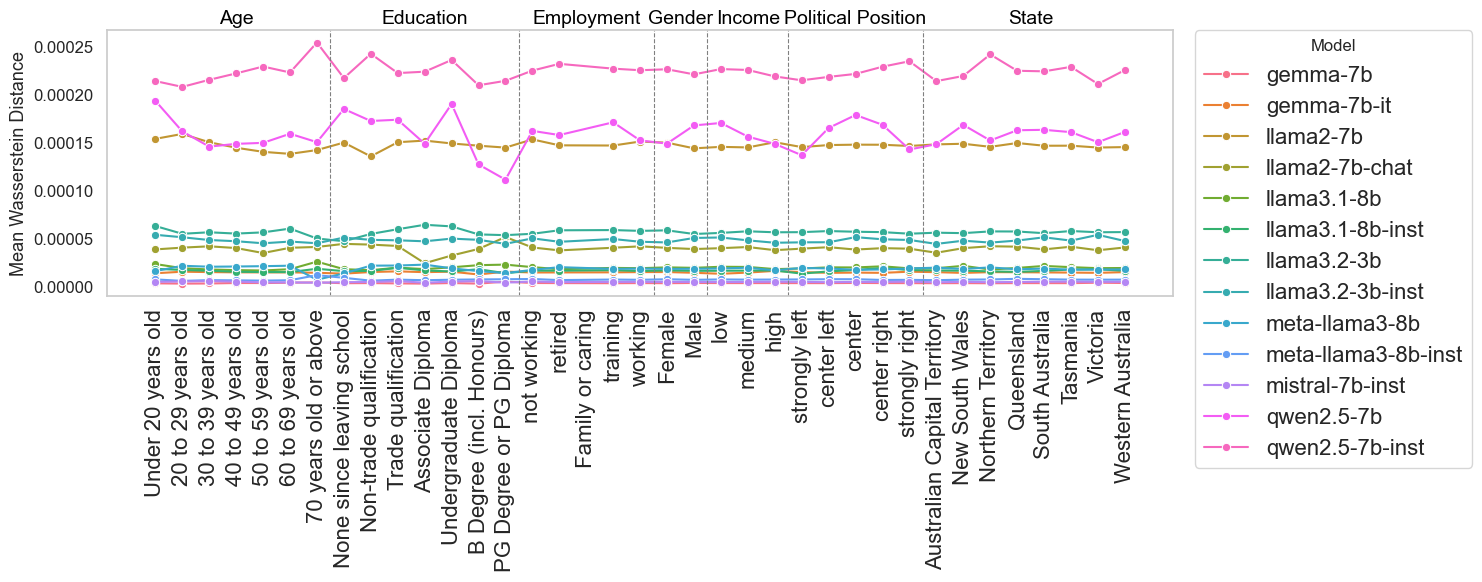

In [33]:

features = ['GENDER', 'EDUCATION', 'INCOME', 'EMPLOYMENT',
            'POLITICAL LEANING', 'STATE', 'AGE']
df = full_data_wess_merged_df.copy()
long_df = pd.melt(
    df,
    id_vars=['model', 'persona_id', 'wasserstein_distance'],
    value_vars=features,
    var_name='feature',
    value_name='feature_value'
)

grouped = long_df.groupby(['model', 'feature', 'feature_value'])['wasserstein_distance'].mean().reset_index()

feature_name_map = {
    "POLITICAL LEANING": "Political Position"
}

grouped["feature_display"] = grouped["feature"].map(
    lambda f: feature_name_map.get(f, f.capitalize())
)

edu_map = {
    "No qualification since leaving school": "None since leaving school",
    "Bachelor Degree (including Honours)": "B Degree (incl. Honours)",
    "Postgraduate Degree or Postgraduate Diploma": "PG Degree or PG Diploma",
}

mask_edu = grouped["feature_display"] == "Education"
grouped.loc[mask_edu, "feature_value"] = (
    grouped.loc[mask_edu, "feature_value"].replace(edu_map)
)

custom_orders = {
    "Age": [
        "Under 20 years old",
        "20 to 29 years old",
        "30 to 39 years old",
        "40 to 49 years old",
        "50 to 59 years old",
        "60 to 69 years old",
        "70 years old or above"
    ],
    "Income": ["low", "medium", "high"],
    "Employment": ["not working", "retired", "Family or caring", "training", "working"],
    "Political Position": ["strongly left", "center left", "center", "center right", "strongly right"],
    "Education": [
        "None since leaving school",
        "Non-trade qualification",
        "Trade qualification",
        "Associate Diploma",
        "Undergraduate Diploma",
        "B Degree (incl. Honours)",
        "PG Degree or PG Diploma"
    ],
}

ordered_x = []
for feat, subdf in grouped.groupby("feature_display"):
    if feat in custom_orders:
        ordered_x.extend(custom_orders[feat])
    else:
        ordered_x.extend(sorted(subdf["feature_value"].unique()))

grouped["x_label"] = pd.Categorical(grouped["feature_value"], categories=ordered_x, ordered=True)

x_positions = {label: i for i, label in enumerate(ordered_x)}
grouped["x_pos"] = grouped["x_label"].map(x_positions)

plt.figure(figsize=(15, 6))
sns.lineplot(data=grouped, x='x_pos', y='wasserstein_distance', hue='model', marker='o')

plt.grid(axis='y', visible=False) 

plt.xticks(ticks=list(x_positions.values()), labels=list(x_positions.keys()), rotation=90,fontsize=16)
plt.ylabel("Mean Wasserstein Distance",fontsize=13)
plt.xlabel("")  
plt.yticks(fontsize=12)

feature_groups = grouped.groupby('feature')['x_pos'].agg(['min', 'max']).reset_index()
#grouped.to_csv("data_Wasserstein_Distance_plot.csv")

feature_name_map = {
    "POLITICAL LEANING": "Political Position"
}

for idx, row in feature_groups.iterrows():
    if idx > 0:  
        plt.axvline(x=row['min'] - 0.5, color='gray', linestyle='--', linewidth=0.8)

    display_name = feature_name_map.get(row['feature'], row['feature'].capitalize())

    midpoint = (row['min'] + row['max']) / 2
    plt.text(
        midpoint,
        plt.ylim()[1] * 1.01,  
        display_name,
        ha='center', va='bottom',
        fontsize=14, color='black'
    )
    
plt.grid(False)
plt.legend(title="Model",fontsize=16, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig("wd_prompt_variant_ready.png")
plt.show()


In [18]:
models = {
    # LLaMA 3.1
    "llama3.1-8b": "meta-llama/Llama-3.1-8B",
    "llama3.1-8b-inst": "meta-llama/Llama-3.1-8B-Instruct",
    
    # Meta-LLaMA 3 
    "meta-llama3-8b": "meta-llama/Meta-Llama-3-8B",
    "meta-llama3-8b-inst": "meta-llama/Meta-Llama-3-8B-Instruct",
    
    # LLaMA 3.2
    "llama3.2-3b": "meta-llama/Llama-3.2-3B",
    "llama3.2-3b-inst": "meta-llama/Llama-3.2-3B-Instruct",

    # LLaMA 2
    "llama2-7b": "meta-llama/Llama-2-7b-hf",
    "llama2-7b-chat": "meta-llama/Llama-2-7b-chat-hf",
    
    # Mistral
    "mistral-7b-inst": "mistralai/Mistral-7B-Instruct-v0.1",
    
    # Gemma
    "gemma-7b": "google/gemma-7b", 
    "gemma-7b-it": "google/gemma-7b-it",
    
    # Qwen
    "qwen2.5-7b": "Qwen/Qwen2.5-7B",
    "qwen2.5-7b-inst": "Qwen/Qwen2.5-7B-Instruct"
}
datasets = {
    "A_AllSameLabel": "TrainDataAllYears/Ful_DatasetAllYears.csv",
}

type_prompts = ["NoSys"]
prompt_variants = [1, 3]
iterations = [1, 2, 3] 
profile_path = "DataSurveyProfiles/CartesianProduct_SynteticData_2.csv"
AES_data = "DataSurveyProfiles/AustraliaVoting2022_15_06.csv"
metrics_files = [
    "metrics_Australian Greens.json",
    "metrics_Australian Labor Party.json",
    "metrics_Liberal Party of Australia.json",
    "metrics_National Party of Australia.json",
]

### Fig. 3. Mean JS

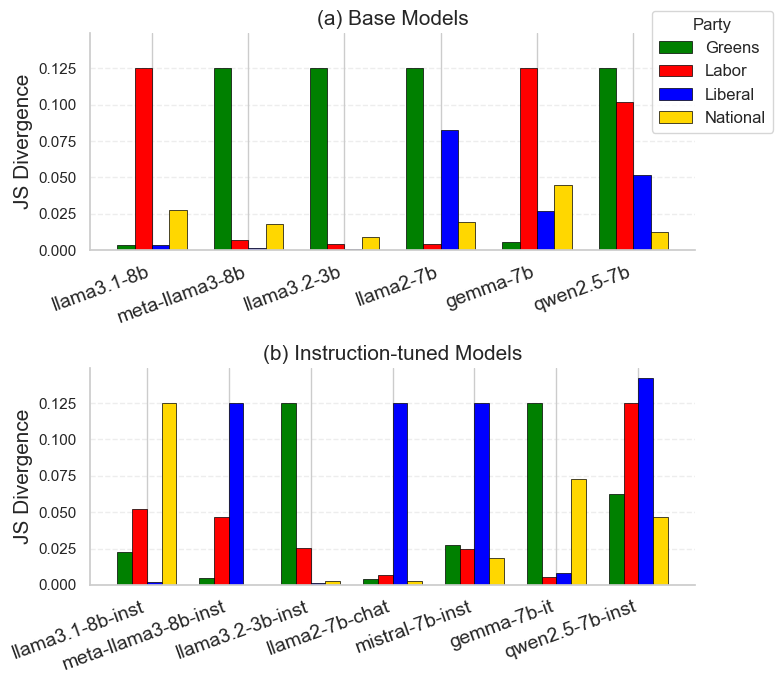

In [50]:
# --- Plot: grouped bar charts instead of lines ---
import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd

def _normalize_probs(x: np.ndarray) -> np.ndarray:
    """Normalize a nonnegative vector to a proper probability distribution.
    If sum==0, return a uniform distribution."""
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0, None)  # no negatives
    s = x.sum()
    if s == 0:
        return np.ones_like(x) / len(x)
    return x / s

def _jsd_per_party(P: np.ndarray, Q: np.ndarray, base: int = 2):
    """Return (total_jsd, per_party_jsd_contrib) in 'bits' if base=2."""
    # Ensure valid distributions
    P = _normalize_probs(P)
    Q = _normalize_probs(Q)
    M = 0.5 * (P + Q)

    # Safe log ratio in chosen base, with 0 * log(0/.) := 0 convention
    def safe_log_ratio(a, b):
        mask = (a > 0) & (b > 0)
        out = np.zeros_like(a, dtype=float)
        out[mask] = np.log(a[mask] / b[mask]) / np.log(base)
        return out

    # Component-wise contributions: 0.5 * [P_i log(P_i/M_i) + Q_i log(Q_i/M_i)]
    contrib = 0.5 * (P * safe_log_ratio(P, M) + Q * safe_log_ratio(Q, M))
    total_jsd = contrib.sum()

    # Optional cross-check using scipy (returns distance; square it for divergence)
    # jsd_check = jensenshannon(P, Q, base=base)**2  # should match total_jsd (up to tiny fp error)

    return total_jsd, contrib

def compute_divergence_by_feature_by_party(aes_df, llm_df, feature_col, vote_col, weight_col, party_cols):
    """
    Computes Jensen–Shannon divergence by subgroup and per party.
    - P (AES) comes from weighted counts over vote_col, reindexed to party_cols.
    - Q (LLM) comes from summed predictions in llm_df[party_cols], shifted if negatives, then normalized.
    Returns a tidy DataFrame with per-party contributions and group totals.
    """
    results = []

    for group_value in aes_df[feature_col].dropna().unique():
        # Subset AES and LLM for the group
        aes_group = aes_df[aes_df[feature_col] == group_value]
        llm_group = llm_df[llm_df[feature_col] == group_value]

        if aes_group.empty or llm_group.empty:
            continue

        # 1) AES empirical distribution P over parties
        aes_dist = aes_group.groupby(vote_col)[weight_col].sum().reindex(party_cols, fill_value=0)
        P_raw = aes_dist.values
        P = _normalize_probs(P_raw)

        # 2) LLM predicted distribution Q over parties (sum over rows, allowing negatives then shift)
        psi = llm_group[party_cols].sum().values.astype(float)
        if np.min(psi) < 0:
            psi = psi - np.min(psi)
        Q = _normalize_probs(psi)

        # 3) Jensen–Shannon divergence (bits) and per-party contributions
        jsd_total, jsd_contrib = _jsd_per_party(P, Q, base=2)

        # Emit rows per party with the per-party contribution; include group total on each row for convenience
        for i, party in enumerate(party_cols):
            results.append({
                "Feature": feature_col,
                "Group": group_value,
                "Party": party,
                "JSD_contrib_bits": jsd_contrib[i],
                "JSD_total_bits": jsd_total
            })

    return pd.DataFrame(results)
    
# --- Inputs you already have elsewhere ---
aes_path = "DataSurveyProfiles/AustraliaVoting2022_15_0_copy.csv"
aes_df = pd.read_csv(aes_path)

# Rename AES columns to match 'profiles'
aes_df = aes_df.rename(columns={
    'Age_binned_1_label': 'AGE',
    'INCOME_CODED': 'INCOME',
    'EMPLOYMENT_CODED': 'EMPLOYMENT',
    'POLITICAL_POSITION_CODED': 'POLITICAL'
})
# Load persona profile data (unchanged)
profile_path = "DataSurveyProfiles/CartesianProduct_SynteticData_2.csv"
profiles = pd.read_csv(profile_path)
profiles = profiles.rename(columns={
    'Age_binned_1_label': 'AGE',
    'INCOME_CODED': 'INCOME',
    'EMPLOYMENT_CODED': 'EMPLOYMENT',
    'POLITICAL_POSITION_CODED': 'POLITICAL'
})
categorical_cols = ['AGE', 'GENDER', 'EDUCATION', 'INCOME', 'EMPLOYMENT', 'POLITICAL', 'STATE']
sociopolitical_features = ['AGE', 'GENDER', 'EDUCATION', 'INCOME', 'EMPLOYMENT', 'POLITICAL', 'STATE']
for col in categorical_cols:
    profiles[col] = profiles[col].astype("category")


def load_all_scaling_for_model(model_short: str) -> pd.DataFrame:
    """
    Collect all scaling_matrix CSVs for a single model across datasets / prompts / iterations.
    Returns a concatenated DataFrame or an empty DataFrame if nothing found.
    """
    pooled = []  # reset per model
    for dataset_short, _CSV_PATH in datasets.items():
        for type_prompt in type_prompts:
            for prompt_variant in prompt_variants:
                for iteration in iterations:
                    path_directory = f"top_val_vec_{model_short}_{dataset_short}{type_prompt}/"
                    file_name = f"scaling_matrix_{prompt_variant}_{iteration}.csv"
                    full_path = os.path.join(path_directory, file_name)
                    if not os.path.isfile(full_path):
                        # skip missing runs without crashing
                        continue
                    try:
                        pooled.append(pd.read_csv(full_path, encoding="utf-8"))
                    except Exception as e:
                        print(f"[WARN] Failed reading {full_path}: {e}")
                        continue

    if not pooled:
        return pd.DataFrame()

    combined = pd.concat(pooled, ignore_index=True)
    return combined

def build_llm_persona_means(combined: pd.DataFrame) -> pd.DataFrame:
    """Average over runs to persona-level party probabilities and merge with profiles."""
    avg_df = combined.groupby("persona_id")[party_cols].mean().reset_index()
    merged = pd.merge(avg_df, profiles, on="persona_id", how="inner")
    return merged

def compute_js_by_feature(merged_df_llm: pd.DataFrame) -> pd.DataFrame:
    """Run your divergence function across all features; returns tidy rows with Party, Group, JSD_contrib_bits."""
    all_results_js = []
    for feature in sociopolitical_features:
        df_result = compute_divergence_by_feature_by_party(
            aes_df=aes_df,
            llm_df=merged_df_llm,
            feature_col=feature,
            vote_col='AES',
            weight_col='weight_final',
            party_cols=party_cols
        )
        all_results_js.append(df_result)
    if not all_results_js:
        return pd.DataFrame()
    return pd.concat(all_results_js, ignore_index=True)


PARTY_ORDER = ["Greens", "Labor", "Liberal", "National"]

PARTY_COLORS = {
    "Greens": "green",
    "Labor": "red",
    "Liberal": "blue",
    "National": "gold",
}

PARTY_RENAME = {
    "Australian Greens": "Greens",
    "Australian Labor Party": "Labor",
    "Liberal Party of Australia": "Liberal",
    "National Party of Australia": "National",
}

# --- Helper to classify models ---
def is_tuned(model_short: str) -> bool:
    """Heuristic: treat chat/inst/it/instruct variants as tuned."""
    s = model_short.lower()
    return any(k in s for k in ["-chat", "-inst", "-it", "instruct"])

# --- Build all_models_js if you don't already have it ---
# Expectation: you already have the functions you shared earlier:
#   load_all_scaling_for_model, build_llm_persona_means, compute_js_by_feature
# and a dict `models` with the order you want on the x-axis.

all_results = []
for model_short, MODEL_NAME in models.items():
    combined_df_js = load_all_scaling_for_model(model_short)
    if combined_df_js.empty:
        continue
    merged_df_llm = build_llm_persona_means(combined_df_js)
    js_df = compute_js_by_feature(merged_df_llm)
    if {"Party","Feature","Group","JSD_contrib_bits"}.issubset(js_df.columns):
        tmp = js_df.copy()
        tmp["model"] = model_short
        tmp["tuned"] = is_tuned(model_short)
        all_results.append(tmp)

if not all_results:
    raise ValueError("No JSD results found.")

all_models_js = pd.concat(all_results, ignore_index=True)

# --- Aggregate to a single JS value per (model, party) ---
# Mean over features and subgroups (you can switch to median if you prefer)
agg = (all_models_js
       .groupby(["model", "tuned", "Party"], as_index=False)["JSD_contrib_bits"]
       .mean()
       .rename(columns={"JSD_contrib_bits": "JS"}))

agg.to_csv('js_data_results.csv')

agg["Party"] = agg["Party"].replace(PARTY_RENAME)

# --- Build x-axis orders from your models dict (keeps your preferred ordering) ---
model_order_base  = [m for m in models.keys() if not is_tuned(m) and m in agg["model"].unique()]
model_order_tuned = [m for m in models.keys() if     is_tuned(m) and m in agg["model"].unique()]

# --- Split frames for plotting ---
df_base  = agg[agg["tuned"] == False]
df_tuned = agg[agg["tuned"] == True]

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharey=True)

panels = [
    ("(a) Base Models",  df_base,  model_order_base,  axes[0]),
    ("(b) Instruction-tuned Models", df_tuned, model_order_tuned, axes[1]),
]

bar_width = 0.18  # width for each party bar
for title, dfp, order, ax in panels:
    # pivot to shape (models x parties) in the desired order
    pivot = (dfp.pivot(index="model", columns="Party", values="JS")
                .reindex(order))  # rows in model order
    x = np.arange(len(order))
    # center the grouped bars around each model position
    offsets = np.linspace(-(len(PARTY_ORDER)-1)/2, (len(PARTY_ORDER)-1)/2, len(PARTY_ORDER)) * bar_width

    # draw bars by party
    for i, party in enumerate(PARTY_ORDER):
        y = pivot[party].values if party in pivot.columns else np.full(len(order), np.nan)
        ax.bar(x + offsets[i], y, width=bar_width,
               label=party,
               edgecolor="black", linewidth=0.5,
               color=PARTY_COLORS.get(party, "gray"))

    ax.set_title(title,fontsize=15)
    ax.set_ylabel("JS Divergence", fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=20, ha="right", fontsize=14)
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    # optional: light frame off
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# One legend for both panels (top-right)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels,fontsize=12, title="Party", loc="upper right", bbox_to_anchor=(0.985, 0.985))

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for legend
plt.savefig("js_divergence_bars_ready.png", dpi=300, bbox_inches="tight")
plt.show()


### Fig. 4. Voting outcome entropy across sociodemographic subgroups 

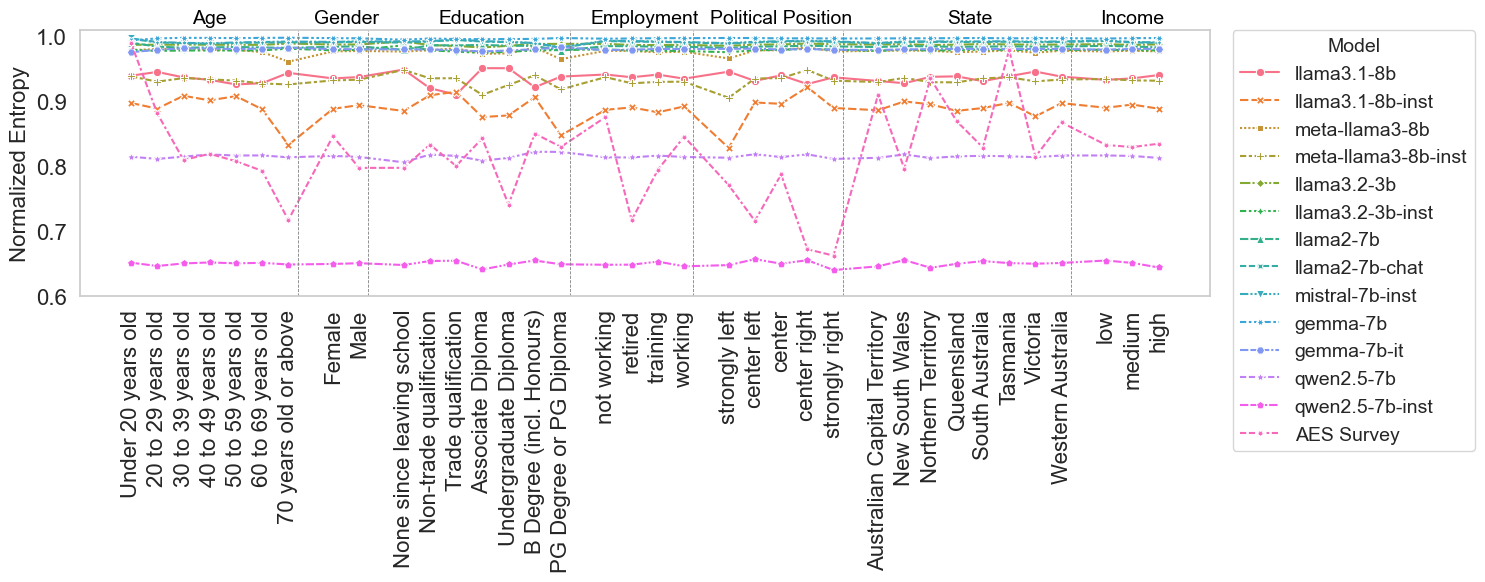

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FEATURE_NAME_MAP = {
    "Age_binned_1_label": "Age",
    "EDUCATION": "Education",
    "EMPLOYMENT_CODED": "Employment",
    "GENDER": "Gender",
    "INCOME_CODED": "Income",
    "POLITICAL_POSITION_CODED": "Political Position",
    "STATE": "State",}

# ===== SUPPORT FUNCTIONS ====
def merge_main_with_llm(main_df, llm_df, output_path=None):
    # Ensure persona_id exists in main_df
    if 'persona_id' not in main_df.columns:
        main_df = main_df.copy()
        main_df['persona_id'] = range(len(main_df))

    llm_cols = ['persona_id'] + [col for col in llm_df.columns if col != 'persona_id']

    merged_df = main_df.merge(llm_df[llm_cols], on='persona_id', how='inner')

    if output_path:
        merged_df.to_csv(output_path, index=False)
    
    return merged_df
    
def entropy_by_party(df, party_cols, model_name):
    df = df.copy()
    df["Entropy"] = df[party_cols].apply(lambda row: compute_normalized_entropy(row.values), axis=1)
    df["Predicted_Party"] = df[party_cols].idxmax(axis=1)
    summary = df.groupby("Predicted_Party")["Entropy"].mean().reset_index()
    summary["Model"] = model_name
    return summary

def compute_normalized_entropy(prob_vector):
    prob_vector = prob_vector[prob_vector > np.finfo(float).eps]
    if len(prob_vector) <= 1:
        return 0
    entropy = -np.sum(prob_vector * np.log2(prob_vector))
    max_entropy = np.log2(len(prob_vector))
    return entropy / max_entropy if max_entropy > 0 else 0

def softmax(x):
    e_x = np.exp(x - np.max(x))  # stability
    return e_x / e_x.sum()

def entropy_by_subgroup(df, feature_col, party_cols):
    results = []

    for subgroup_value, group_df in df.groupby(feature_col):
        psi = group_df[party_cols].sum().values.astype(float)
        min_val = np.min(psi)
        if min_val < 0:
            psi = psi - min_val  # Shift all ≥ 0

        prob_dist = psi / np.sum(psi) if np.sum(psi) != 0 else np.ones_like(psi) / len(psi)
        
        norm_entropy = compute_normalized_entropy(prob_dist)
        certanty = 1 - norm_entropy

        results.append({
            'Feature': feature_col,
            'Subgroup': subgroup_value,
            'Entropy': norm_entropy,
            'Certanty': certanty
        })
    return pd.DataFrame(results)

def entropy_from_aes_votes(df, feature_col, vote_col, weight_col=None, party_labels=None):
    results = []

    for subgroup_value, group_df in df.groupby(feature_col):
        if subgroup_value == "Prefer not to say":
            continue  # Skip this subgroup
            
        if weight_col is None:
            # Unweighted counts
            vote_counts = group_df[vote_col].value_counts().reindex(party_labels, fill_value=0)
        else:
            # Weighted counts
            vote_counts = group_df.groupby(vote_col)[weight_col].sum().reindex(party_labels, fill_value=0)

        prob_dist = vote_counts.values
        if np.sum(prob_dist) == 0:
            prob_dist = np.ones_like(prob_dist) / len(prob_dist)
        else:
            prob_dist = prob_dist / np.sum(prob_dist)

        norm_entropy = compute_normalized_entropy(prob_dist)
        certanty = 1 - norm_entropy
        results.append({
            'Feature': feature_col,
            'Subgroup': subgroup_value,
            'Entropy': norm_entropy,
            'Certanty': certanty
        })

    return pd.DataFrame(results)


def load_model_entropy(llm_df, main_df, model_filepath,file_name, model_name, features, party_cols):
    df = merge_main_with_llm(main_df, llm_df, output_path=None)
    entropy_df = pd.concat([entropy_by_subgroup(df, f, party_cols) for f in features], ignore_index=True)
    entropy_df["Model"] = model_name
    return entropy_df

party_cols = [
    "Australian Greens",
    "Australian Labor Party",
    "Liberal Party of Australia",
    "National Party of Australia"
]

aes_mapping = {
    "Labor": "Australian Labor Party",
    "Liberal": "Liberal Party of Australia",
    "National Party": "National Party of Australia",
    "Greens": "Australian Greens"
}

sociopolitical_features = ['Age', "Gender", "Education", "Employment", "Political Position", 'State','Income']


aes_df = pd.read_csv("DataSurveyProfiles/AustraliaVoting2022_15_06.csv", encoding="utf-8")
aes_df["AES"] = aes_df["AES"].map(aes_mapping)
aes_df = aes_df.rename(columns=FEATURE_NAME_MAP)

main_df = pd.read_csv(profile_path, encoding="utf-8")
main_df = main_df.rename(columns=FEATURE_NAME_MAP)


entropy_list = []
pooled = []
for model_short, MODEL_NAME in models.items():
    for dataset_short, CSV_PATH in datasets.items():
        for type_prompt in type_prompts:
            for prompt_variant in prompt_variants:
                for iteration in iterations:
                    path_directory = f"top_val_vec_{model_short}_{dataset_short}{type_prompt}/"
                    file_name = f"scaling_matrix_{prompt_variant}_{iteration}.csv"
                    name_var_entropy = f"{model_short}_entropy"
                    full_path = f"{path_directory}{file_name}"
                    # Load entropy
                    pooled.append(pd.read_csv(full_path, encoding="utf-8"))
        llm_all = pd.concat(pooled, ignore_index=True)
        entropy_df = load_model_entropy(
                        llm_all,
                        main_df,
                        path_directory,
                        file_name,
                        model_short,
                        sociopolitical_features,
                        party_cols
                    )
        
        entropy_df["Run_Label"] = name_var_entropy
                    
        entropy_list.append(entropy_df)


aes_entropy = pd.concat([
    entropy_from_aes_votes(aes_df, f, vote_col="AES", weight_col="weight_final", party_labels=party_cols)
    for f in sociopolitical_features
], ignore_index=True)

aes_entropy["Model"] = "AES Survey"

all_entropy_data = pd.concat(entropy_list + [aes_entropy], ignore_index=True)

custom_orders = {
    "Age": [
        "Under 20 years old",
        "20 to 29 years old",
        "30 to 39 years old",
        "40 to 49 years old",
        "50 to 59 years old",
        "60 to 69 years old",
        "70 years old or above"
    ],
    "Income": ["low", "medium", "high"],
    "Employment": ["not working", "retired", "Family/caring", "training", "working"],
    "Political Position": ["strongly left", "center left","center", "center right", "strongly right"],
    "Education": [
        'None since leaving school',#"No qualification since leaving school",
        "Non-trade qualification",
        "Trade qualification",
        "Associate Diploma",
        "Undergraduate Diploma",
        "B Degree (incl. Honours)",#"Bachelor Degree (including Honours)",
        "PG Degree or PG Diploma" #"Postgraduate Degree or Postgraduate Diploma"
    ],
    # Gender, State will fallback to sorted() since no explicit order
}

plt.figure(figsize=(15, 6))

#all_entropy_data.to_csv("entropy_data_results.csv")

all_entropy_data = pd.concat(entropy_list + [aes_entropy], ignore_index=True)

edu_map = {
    "No qualification since leaving school": "None since leaving school",
    "Bachelor Degree (including Honours)": "B Degree (incl. Honours)",
    "Postgraduate Degree or Postgraduate Diploma": "PG Degree or PG Diploma",
}

mask = all_entropy_data["Feature"] == "Education"
all_entropy_data.loc[mask, "Subgroup"] = (
    all_entropy_data.loc[mask, "Subgroup"].replace(edu_map)
)

plot_df = all_entropy_data.dropna(subset=['Feature', 'Subgroup']).copy()

feature_order = ['Age', 'Gender', 'Education', 'Employment', 'Political Position', 'State', 'Income']
plot_df['Feature'] = pd.Categorical(plot_df['Feature'], categories=feature_order, ordered=True)

value_order = {}
for feat in feature_order:
    if feat in custom_orders:
        # Only keep subgroups that actually appear in data
        present = plot_df.loc[plot_df['Feature'] == feat, 'Subgroup'].unique()
        order = [v for v in custom_orders[feat] if v in present]
    else:
        order = sorted(plot_df.loc[plot_df['Feature'] == feat, 'Subgroup'].dropna().unique(), key=str)
    value_order[feat] = order

x_pairs = []
pos = 0.0
gap = 0.7
for feat in feature_order:
    vals = value_order[feat]
    for v in vals:
        x_pairs.append(((feat, v), pos))
        pos += 1.0
    if len(vals) > 0:
        pos += gap
pos_map = dict(x_pairs)

# Add x_pos
plot_df['x_pos'] = plot_df.apply(lambda r: pos_map.get((r['Feature'], r['Subgroup'])), axis=1)
plot_df = plot_df.dropna(subset=['x_pos'])


ax = sns.lineplot(
    data=plot_df,
    x='x_pos',
    y='Entropy',
    hue='Model',
    style='Model',
    markers=True,
    dashes=True
)

ax.set_ylabel("Normalized Entropy", fontsize=16)#, fontweight='bold')
ax.tick_params(axis='y', labelsize=16)

ax.set_xlabel("")

ax.set_ylim(0.6, 1.01)
tick_positions = []
tick_labels = []
for feat in feature_order:
    for v in value_order[feat]:   # dict indexing, not .loc
        tick_positions.append(pos_map[(feat, v)])
        tick_labels.append(str(v))

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='center', fontsize=16)

ax.yaxis.grid(False)
plt.grid(False)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=14,        
    title_fontsize=14  
)

from matplotlib.transforms import blended_transform_factory
trans = blended_transform_factory(ax.transData, ax.transAxes)

feature_bounds = (plot_df.groupby('Feature', observed=True)['x_pos']
                  .agg(['min', 'max']).reset_index())

for i, row in feature_bounds.iterrows():
    xmin, xmax = row['min'], row['max']
    mid = (xmin + xmax) / 2.0

    ax.annotate(str(row['Feature']), xy=(mid, 1.01), xycoords=trans,
                ha='center', va='bottom', fontsize=14, color='black')

    if i < len(feature_bounds) - 1:
        ax.axvline(x=xmax + gap/2.0, color='gray',
                   linestyle='--', linewidth=0.6)

plt.subplots_adjust(left=0.1, right=0.82, top=0.9, bottom=0.28)
plt.tight_layout()  

plt.savefig("entropy_ready.png", bbox_inches='tight', dpi=200)
plt.show()

### Fig. 5. Regression coefficients of sociodemographic predictors on party-specific scaling factors for each party,

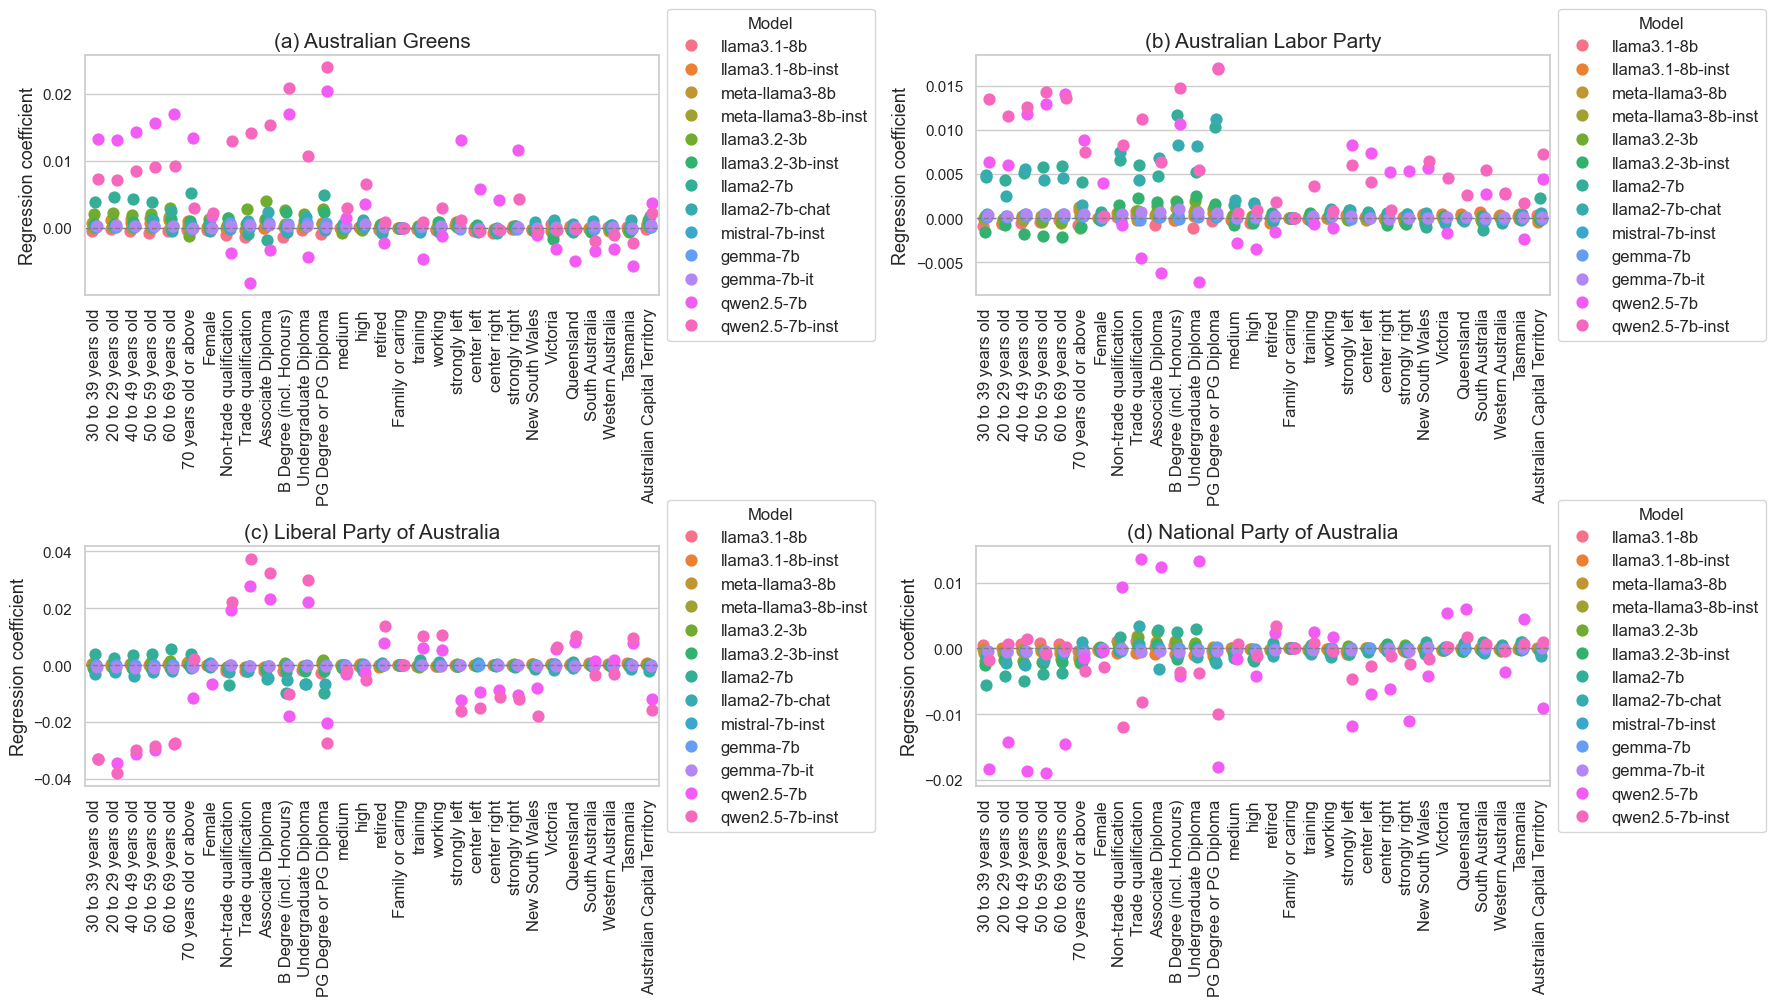

In [27]:
import os
import re
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

custom_orders = {
    "Age": [
        "Under 20 years old",
        "30 to 39 years old",
        "20 to 29 years old",
        "40 to 49 years old",
        "50 to 59 years old",
        "60 to 69 years old",
        "70 years old or above"
    ],
    "Income": ["low", "medium","high"],
    "Employment": ["not working", "retired", "Family or caring", "training","working"],
    "Political Position": ["center", "strongly left", "center left", "center right", "strongly right"],
    "Education": [
        "No qualification since leaving school",
        "Non-trade qualification",
        "Trade qualification",
        "Associate Diploma",
        "Bachelor Degree (including Honours)",
        "Undergraduate Diploma",
        "Postgraduate Degree or Postgraduate Diploma"
    ],
    "Gender": ["Male", "Female"],
    "State": [
         "Northern Territory","New South Wales", "Victoria", "Queensland",
        "South Australia","Western Australia","Tasmania","Australian Capital Territory"
    ],
}

edu_map = {
    "Bachelor Degree (including Honours)": "B Degree (incl. Honours)",
    "Postgraduate Degree or Postgraduate Diploma": "PG Degree or PG Diploma",
}

custom_orders["Education"] = [
    edu_map.get(level, level) for level in custom_orders["Education"]
]


orders = {**custom_orders}
orders["Political_Position"] = orders.pop("Political Position")

predictors = ['Age', 'Gender', 'Education', 'Income',
              'Employment', 'Political_Position', 'State']

parties = [
    'Australian Greens',
    'Australian Labor Party',
    'Liberal Party of Australia',
    'National Party of Australia'
]

all_coefs = []

for model_short, MODEL_NAME in models.items():
    pooled = []
    for dataset_short, CSV_PATH in datasets.items():
        for type_prompt in type_prompts:
            for prompt_variant in prompt_variants:
                for iteration in iterations:
                    path_directory = f"top_val_vec_{model_short}_{dataset_short}{type_prompt}/"
                    file_name = f"scaling_matrix_{prompt_variant}_{iteration}.csv"
                    full_path = f"{path_directory}{file_name}"
                    if os.path.exists(full_path):
                        df = pd.read_csv(full_path, encoding="utf-8")
                        df["model_short"] = model_short
                        pooled.append(df)

    if not pooled:
        continue

    llm_all = pd.concat(pooled, ignore_index=True)

    df_llm_all = merge_main_with_llm(main_df, llm_all, output_path=None)
    df_llm_all = df_llm_all.rename(columns={"Political Position": "Political_Position"})

    if "Education" in df_llm_all.columns:
        df_llm_all["Education"] = df_llm_all["Education"].replace(edu_map)

    for col in predictors:
        if col in df_llm_all.columns:
            if col in orders:
                df_llm_all[col] = pd.Categorical(
                    df_llm_all[col],
                    categories=orders[col],
                    ordered=True
                )
            else:
                df_llm_all[col] = df_llm_all[col].astype("category")

    rhs_terms = []
    for col in predictors:
        if col in orders:
            ref = orders[col][0]  # first in your custom order
            rhs_terms.append(f'C({col}, Treatment(reference="{ref}"))')
        else:
            rhs_terms.append(f'C({col})')  # safety fallback

    for party in parties:
        if party not in df_llm_all.columns:
            continue

        formula = f'Q("{party}") ~ ' + " + ".join(rhs_terms)
        model = smf.ols(formula, data=df_llm_all).fit()
        baseline_levels = {col: (orders[col][0] if col in orders else None) for col in predictors}
        
        intercept = model.params["Intercept"]
        intercept_ci_low, intercept_ci_high = model.conf_int().loc["Intercept"]
        intercept_pval = model.pvalues["Intercept"]
        
        conf = model.conf_int()

        for term, coef in model.params.items():
            if term == "Intercept":
                continue
            pval = model.pvalues[term]
            all_coefs.append({
                "party": party,
                "model_short": model_short,
                "feature_term": term,
                "coef": coef,
                "conf_low": conf.loc[term, 0],
                "conf_high": conf.loc[term, 1],
                "pval": pval,
                "significant": pval <= 0.05
            })

coef_df = pd.DataFrame(all_coefs)

coef_df = coef_df[coef_df["significant"] == True].copy()

coef_df["feature_term"] = coef_df["feature_term"].astype(str)
coef_df["level_clean"] = coef_df["feature_term"].str.extract(r"\[T\.(.*?)\]")
coef_df["feature_clean"] = coef_df["feature_term"].str.extract(r"C\((?:C\()?(?P<feat>[^,)\]]+)")
coef_df["term_label"] = coef_df["level_clean"].fillna(coef_df["feature_term"])

term_order = []

for feat in predictors:
    if feat in orders:  # Age, Gender, Education, Income, Employment, Political_Position, State
        for level in orders[feat]:
            if ((coef_df["feature_clean"] == feat) &
                (coef_df["level_clean"] == level)).any():
                term_order.append(level)

order_terms = (coef_df
               .dropna(subset=["feature_clean", "level_clean"])
               .sort_values(["feature_clean", "level_clean"])
               ["term_label"]
               .unique()
               .tolist())

coef_df["term_label"] = pd.Categorical(
    coef_df["term_label"],
    categories=term_order,
    ordered=True
)


sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=False)
axes = axes.ravel()
labels = ["(a)", "(b)", "(c)", "(d)"]

for idx, (ax, party) in enumerate(zip(axes, parties)):
    data_p = coef_df[coef_df["party"] == party].copy()
    if data_p.empty:
        ax.set_visible(True)
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.set_title(f"{labels[idx]} {party}", fontsize=14)
        ax.set_xlabel("")
        ax.set_ylabel("Regression coefficient")
        ax.text(0.5, 0.5, "No coefficients at α ≤ 0.05",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.legend([], [], frameon=False)
        continue

    sns.pointplot(
        data=data_p,
        x="term_label",
        y="coef",
        hue="model_short",
        dodge=True,
        linestyle="none",
        errorbar=None,
        order=term_order, 
        ax=ax
    )

    y_min = min(data_p["conf_low"].min(), data_p["coef"].min())
    y_max = max(data_p["conf_high"].max(), data_p["coef"].max())
    pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{labels[idx]} {party}", fontsize=15)
    ax.set_xlabel("")
    ax.set_ylabel("Regression coefficient", fontsize=13)
    ax.tick_params(axis="x", rotation=90, labelsize=12)

    ax.legend(
        title="Model",
        fontsize=12,
        frameon=True,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5)
    )
    
plt.tight_layout()
plt.savefig("regression_sig_ready.png")
plt.show()


In [28]:
coef_df.to_csv("coef_df_significant0.05_ready.csv")

### Fig. 6. Mean Significant Coefficients (α ≤ 0.05) with Z-score normalization within each model and party distribution.


In [ ]:
import os
import re
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

custom_orders = {
    "Age": [
        "Under 20 years old",
        "20 to 29 years old",
        "30 to 39 years old",
        "40 to 49 years old",
        "50 to 59 years old",
        "60 to 69 years old",
        "70 years old or above"
    ],
    "Income": ["low", "medium", "high"],
    "Employment": ["not working", "retired", "Family or caring", "training", "working"],
    "Political Position": ["center", "strongly left", "center left", "center right", "strongly right"],
    "Education": [
        "No qualification since leaving school",
        "Non-trade qualification",
        "Trade qualification",
        "Associate Diploma",
        "Undergraduate Diploma",
        "Bachelor Degree (including Honours)",
        "Postgraduate Degree or Postgraduate Diploma"
    ],
    "Gender": ["Male", "Female"],
    "State": [
        "Northern Territory", "New South Wales", "Victoria", "Queensland",
        "South Australia","Western Australia","Tasmania","Australian Capital Territory"
    ],
}

edu_map = {
    "No qualification since leaving school": "None since leaving school",
    "Bachelor Degree (including Honours)": "B Degree (incl. Honours)",
    "Postgraduate Degree or Postgraduate Diploma": "PG Degree or PG Diploma",
}

custom_orders["Education"] = [
    edu_map.get(level, level) for level in custom_orders["Education"]
]

orders = {**custom_orders}
orders["Political_Position"] = orders.pop("Political Position")

predictors = ['Age', 'Gender', 'Education', 'Income',
              'Employment', 'Political_Position', 'State']

parties = [
    'Australian Greens',
    'Australian Labor Party',
    'Liberal Party of Australia',
    'National Party of Australia'
]

USE_NORMALIZED = True      # <- set False to use raw scaling factors
NORMALIZED_SUFFIX = "__z"  # party column suffix when normalized

def is_tuned(model_short: str) -> bool:
    s = str(model_short).lower()
    return any(k in s for k in ["-chat", "-inst", "-it", "instruct"])

def zscore_by_model(df: pd.DataFrame, party_cols: list, model_col: str = "model_short") -> pd.DataFrame:
    """
    Z-score normalize each party column within each model (per model × party).
    Adds new columns f"{party}{NORMALIZED_SUFFIX}".
    If std == 0, sets result to NaN for those rows.
    """
    out = df.copy()
    for party in party_cols:
        mu = out.groupby(model_col)[party].transform("mean")
        sd = out.groupby(model_col)[party].transform("std")
        # avoid division by zero
        sd = sd.replace(0, np.nan)
        out[f"{party}{NORMALIZED_SUFFIX}"] = (out[party] - mu) / sd
    return out

def build_rhs_terms(pred_cols, orders_map):
    """C(Feature, Treatment(reference='first_level')) for each categorical predictor."""
    rhs = []
    for col in pred_cols:
        if col in orders_map:
            ref = orders_map[col][0]  # first in your custom order -> baseline
            rhs.append(f'C({col}, Treatment(reference="{ref}"))')
        else:
            rhs.append(f"C({col})")
    return rhs

def slugify(s: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', s.lower()).strip('_')

all_coefs = []

for model_short, MODEL_NAME in models.items():
    pooled = []
    for dataset_short, CSV_PATH in datasets.items():
        for type_prompt in type_prompts:
            for prompt_variant in prompt_variants:
                for iteration in iterations:
                    path_directory = f"top_val_vec_{model_short}_{dataset_short}{type_prompt}/"
                    file_name = f"scaling_matrix_{prompt_variant}_{iteration}.csv"
                    full_path = f"{path_directory}{file_name}"
                    if os.path.exists(full_path):
                        df = pd.read_csv(full_path, encoding="utf-8")
                        df["model_short"] = model_short
                        pooled.append(df)

    if not pooled:
        continue

    llm_all = pd.concat(pooled, ignore_index=True)

    df_llm_all = merge_main_with_llm(main_df, llm_all, output_path=None)
    df_llm_all = df_llm_all.rename(columns={"Political Position": "Political_Position"})

    if "Education" in df_llm_all.columns:
        df_llm_all["Education"] = df_llm_all["Education"].replace(edu_map)

    for col in predictors:
        if col in df_llm_all.columns:
            if col in orders:
                df_llm_all[col] = pd.Categorical(
                    df_llm_all[col],
                    categories=orders[col],
                    ordered=True
                )
            else:
                df_llm_all[col] = df_llm_all[col].astype("category")

    if USE_NORMALIZED:
        df_llm_all = zscore_by_model(df_llm_all, parties, model_col="model_short")

    rhs_terms = build_rhs_terms(predictors, orders)

    for party in parties:
        target_col = f"{party}{NORMALIZED_SUFFIX}" if USE_NORMALIZED else party
        if target_col not in df_llm_all.columns:
            continue

        data_fit = df_llm_all.dropna(subset=[target_col]).copy()
        if data_fit.empty:
            continue

        formula = f'Q("{target_col}") ~ ' + " + ".join(rhs_terms)

        model = smf.ols(formula, data=data_fit).fit()
        baseline_levels = {col: (orders[col][0] if col in orders else None) for col in predictors}
        
        intercept = model.params["Intercept"]
        intercept_ci_low, intercept_ci_high = model.conf_int().loc["Intercept"]
        intercept_pval = model.pvalues["Intercept"]
        
        conf = model.conf_int()

        for term, coef in model.params.items():
            if term == "Intercept":
                continue
            pval = model.pvalues[term]
            all_coefs.append({
                "party": party,
                "model_short": model_short,
                "feature_term": term,
                "coef": coef,
                "conf_low": conf.loc[term, 0],
                "conf_high": conf.loc[term, 1],
                "pval": pval,
                "significant": pval <= 0.05,
                "normalized": USE_NORMALIZED
            })

coef_df = pd.DataFrame(all_coefs)

coef_df = coef_df[coef_df["significant"] == True].copy()

coef_df["feature_term"] = coef_df["feature_term"].astype(str)
coef_df["level_clean"] = coef_df["feature_term"].str.extract(r"\[T\.(.*?)\]")
coef_df["feature_clean"] = coef_df["feature_term"].str.extract(r"C\((?:C\()?(?P<feat>[^,)\]]+)")
coef_df["term_label"]   = coef_df["level_clean"].fillna(coef_df["feature_term"])

coef_df["group"] = coef_df["model_short"].apply(lambda m: "Tuned" if is_tuned(m) else "Base")

agg = (coef_df
       .groupby(["party", "feature_term", "feature_clean", "level_clean", "term_label", "group"], as_index=False)
       .agg(coef_mean=("coef", "mean"),
            conf_low_mean=("conf_low", "mean"),
            conf_high_mean=("conf_high", "mean"),
            n=("coef", "size"))
      )

order_terms = (agg
               .dropna(subset=["feature_clean", "level_clean"])
               .sort_values(["feature_clean", "level_clean"])
               ["term_label"]
               .unique()
               .tolist())


if not agg.empty:
    y_min = np.nanmin(agg["conf_low_mean"])
    y_max = np.nanmax(agg["conf_high_mean"])
    # small padding
    y_pad = 0.05 * max(1e-9, (y_max - y_min))
    y_min, y_max = y_min - y_pad, y_max + y_pad
else:
    y_min, y_max = -1, 1  # fallback

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)
axes = axes.ravel()

groups = ["Base", "Tuned"]

for ax, party in zip(axes, parties):
    data_p = agg[agg["party"] == party].copy()

    if data_p.empty:
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(f"{party} — Mean significant coefficients (α ≤ 0.05){' [z-scored]' if USE_NORMALIZED else ''}")
        ax.text(0.5, 0.5, "No significant coefficients after filtering",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_ylim(y_min, y_max)
        continue

    terms = order_terms if len(order_terms) else data_p["term_label"].unique().tolist()
    x = np.arange(len(terms))
    width = 0.42

    means = {g: [np.nan] * len(terms) for g in groups}
    for g in groups:
        sub = data_p[data_p["group"] == g].set_index("term_label")
        for i, t in enumerate(terms):
            if t in sub.index:
                means[g][i] = sub.loc[t, "coef_mean"]

    b1 = ax.bar(x - width/2, means["Base"], width, label="Base")
    b2 = ax.bar(x + width/2, means["Tuned"], width, label="Tuned")

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{party}", fontsize=12, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Mean regression coefficient", , fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(terms, rotation=90, fontsize=12)
    ax.set_ylim(y_min, y_max)

for j in range(len(parties), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="right", ncol=1, frameon=True, fontsize=12)

plt.tight_layout(rect=[0.02, 0.02, 0.95, 0.88])  # leave room for legend & title
plt.savefig("regression_sig_mean_all_parties.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close